# Trem em Estados — Simulação Sem Filtro

Este notebook demonstra a evolução de um **modelo de estados lineares** que representa um trem
em movimento a velocidade constante. Não há aplicação de filtro de Kalman — tratamos apenas
da **propagação determinística** do estado e da comparação com dados reais.

O objetivo é validar que a discretização exata do modelo de estados reproduz
perfeitamente a posição verdadeira do trem ao longo do tempo.

## 1. Imports

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 2. Carregamento dos Dados

O arquivo CSV contém três colunas:

| Coluna | Descrição |
|---|---|
| `n` | Número do passo de tempo (1 a 20) |
| `pos_verdadeira_m` | Posição verdadeira do trem em metros |
| `medicao_pos_m` | Medição ruidosa da posição em metros |

In [3]:
# Caminho relativo ao diretório do notebook
RAIZ = Path().resolve().parent.parent
CAMINHO = RAIZ / "arquivos" / "exemploA_trem.csv"

df = pd.read_csv(CAMINHO)
df

,n,pos_verdadeira_m,medicao_pos_m
0,1,25.0,17.069
1,2,50.0,52.406
2,3,75.0,56.037
3,4,100.0,113.958
4,5,125.0,131.383
5,6,150.0,147.080
6,7,175.0,171.881
7,8,200.0,203.038
8,9,225.0,222.323
9,10,250.0,247.741


## 3. Modelo de Estados

O trem é descrito pelo **modelo de estados contínuo**:

$$\dot{\mathbf{x}}(t) = \mathbf{A}\,\mathbf{x}(t)$$

onde o vetor de estados é:

$$\mathbf{x}(t) = \begin{bmatrix} p(t) \\ v(t) \end{bmatrix}$$

com $p(t)$ sendo a posição e $v(t)$ a velocidade. A matriz de transição é:

$$\mathbf{A} = \begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix}$$

A **saída observável** é apenas a posição:

$$y(t) = \mathbf{C}\,\mathbf{x}(t), \quad \mathbf{C} = \begin{bmatrix} 1 & 0 \end{bmatrix}$$

### Discretização Exata

Para um intervalo de amostragem $\Delta t$, a matriz de transição discreta é obtida pela
série exata da matriz exponencial:

$$\mathbf{F} = e^{\mathbf{A}\Delta t} = \mathbf{I} + \mathbf{A}\Delta t + \frac{\mathbf{A}^2 \Delta t^2}{2!} + \cdots$$

Como $\mathbf{A}^2 = \mathbf{0}$ (matriz nilpotente), a série converge exatamente no segundo termo:

$$\mathbf{F} = \mathbf{I} + \mathbf{A}\,\Delta t = \begin{bmatrix} 1 & \Delta t \\ 0 & 1 \end{bmatrix}$$

Isso equivale à equação cinemática $p_{k+1} = p_k + v_k \, \Delta t$.

## 4. Parâmetros

In [4]:
dt = 1.0          # intervalo de amostragem [s]
N = 20             # número de passos de tempo

# Matrizes do modelo contínuo
A = np.array([[0, 1],
              [0, 0]])
C = np.array([[1, 0]])

# Discretização exata: F = I + A*dt (A² = 0, série converge no 2º termo)
F = np.eye(2) + A * dt + (A @ A) * dt**2 / 2

# Condição inicial: posição = 0 m, velocidade = 25 m/s
x0 = np.array([0.0, 25.0])

print(f"dt = {dt} s")
print(f"A\u00b2 =\n{A @ A}  (nilpotente → série exata em 2 termos)")
print(f"F =\n{F}")
print(f"x₀ = {x0}")

dt = 1.0 s
A² =
[[0 0]
 [0 0]]  (nilpotente → série exata em 2 termos)
F =
[[1. 1.]
 [0. 1.]]
x₀ = [ 0. 25.]


### Tabela de Parâmetros

| Parâmetro | Valor | Significado |
|---|---|---|
| $\Delta t$ | 1 s | Intervalo entre amostras |
| $N$ | 20 | Número de passos de simulação |
| $\mathbf{A}$ | $\begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix}$ | Matriz de transição contínua |
| $\mathbf{C}$ | $\begin{bmatrix} 1 & 0 \end{bmatrix}$ | Matriz de observação (mede posição) |
| $\mathbf{F}$ | $\begin{bmatrix} 1 & 1 \\ 0 & 1 \end{bmatrix}$ | Transição discreta exata |
| $\mathbf{x}_0$ | $[0, 25]^T$ | Estado inicial (posição=0, velocidade=25 m/s) |

## 5. Simulação da Evolução do Estado

A cada passo de tempo, propagamos o estado com a equação:

$$\mathbf{x}_{k+1} = \mathbf{F}\,\mathbf{x}_k$$

e extraímos a saída observável:

$$y_k = \mathbf{C}\,\mathbf{x}_k$$

In [5]:
# Vetor de posições verdadeiras do CSV (referência)
pos_verdadeira = df["pos_verdadeira_m"].to_numpy()

# Evolução determinística do estado sem filtro
x = x0.copy()
saidas = np.zeros(N)
estados = np.zeros((N, 2))

for k in range(N):
    x = F @ x                # propagação do estado
    estados[k] = x           # armazena posição e velocidade
    saidas[k] = (C @ x)[0]   # extrai a posição (saída observável)

# Verificação: saída simulada deve ser idêntica à posição verdadeira
print(f"allclose(saidas, pos_verdadeira) = {np.allclose(saidas, pos_verdadeira)}")

allclose(saidas, pos_verdadeira) = True


## 6. Métricas Estatísticas

Comparação entre a posição simulada (sem filtro) e a posição verdadeira do CSV.

In [6]:
residuos = saidas - pos_verdadeira

rmse = np.sqrt(np.mean(residuos**2))
mae = np.mean(np.abs(residuos))
erro_max = np.max(np.abs(residuos))
vies = np.mean(residuos)
desvio_padrao = np.std(residuos)

print(f"{'Métrica':<30} {'Valor':>12}")
print("-" * 44)
print(f"{'RMSE [m]':<30} {rmse:>12.6f}")
print(f"{'MAE [m]':<30} {mae:>12.6f}")
print(f"{'Erro máximo absoluto [m]':<30} {erro_max:>12.6f}")
print(f"{'Viés [m]':<30} {vies:>12.6f}")
print(f"{'Desvio padrão [m]':<30} {desvio_padrao:>12.6f}")

Métrica                               Valor
--------------------------------------------
RMSE [m]                           0.000000
MAE [m]                            0.000000
Erro máximo absoluto [m]           0.000000
Viés [m]                           0.000000
Desvio padrão [m]                  0.000000


## 7. Visualização dos Resultados

### 7.1 Posição: Simulação vs. Verdadeira

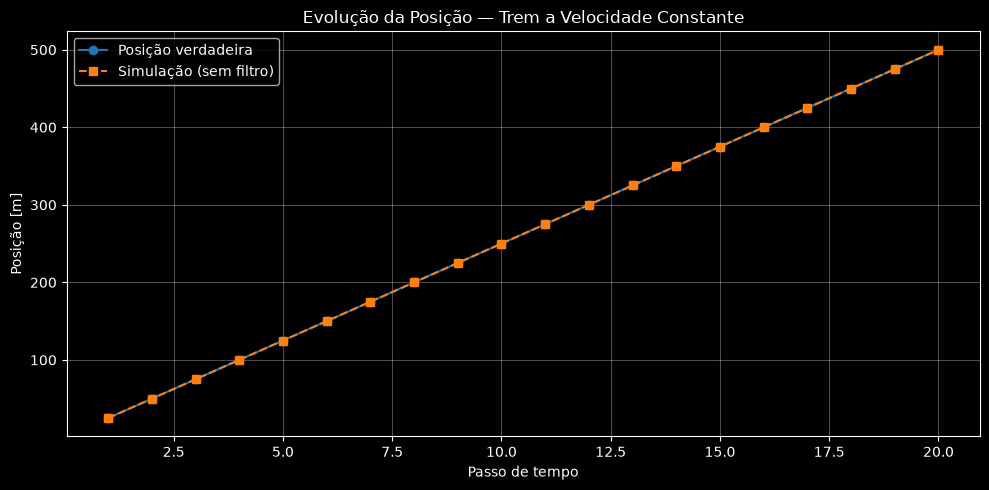

In [7]:
passos = np.arange(1, N + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(passos, pos_verdadeira, "o-", label="Posição verdadeira", color="tab:blue")
ax.plot(passos, saidas, "s--", label="Simulação (sem filtro)", color="tab:orange")
ax.set_xlabel("Passo de tempo")
ax.set_ylabel("Posição [m]")
ax.set_title("Evolução da Posição — Trem a Velocidade Constante")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.2 Erro de Posição (Resíduos)

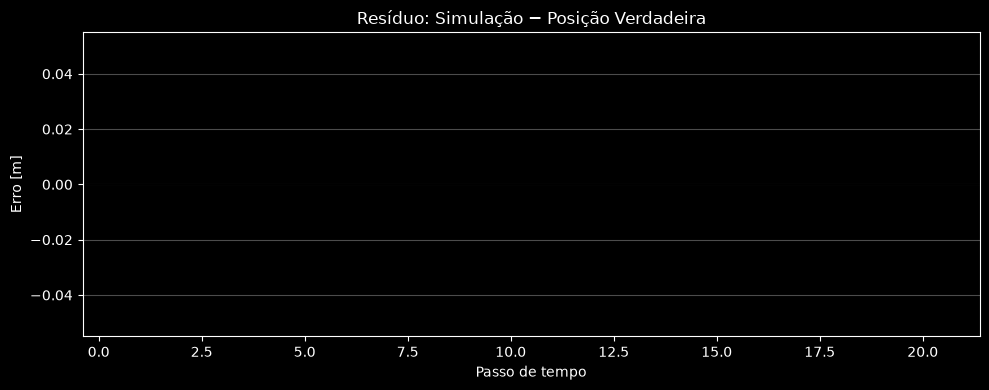

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(passos, residuos, color="tab:red", alpha=0.7)
ax.axhline(y=0, color="black", linewidth=0.8)
ax.set_xlabel("Passo de tempo")
ax.set_ylabel("Erro [m]")
ax.set_title("Resíduo: Simulação − Posição Verdadeira")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### 7.3 Velocidade Estimada

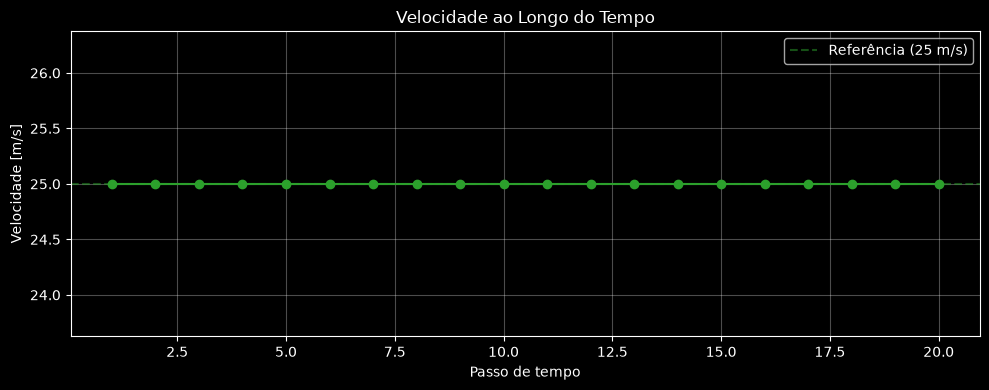

In [9]:
velocidades = estados[:, 1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(passos, velocidades, "o-", color="tab:green")
ax.axhline(y=25.0, color="tab:green", linestyle="--", alpha=0.5, label="Referência (25 m/s)")
ax.set_xlabel("Passo de tempo")
ax.set_ylabel("Velocidade [m/s]")
ax.set_title("Velocidade ao Longo do Tempo")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()